\section{Methodology}

\subsection{Feature Engineering: Temporal and Event-Based Variables}

We developed a comprehensive feature engineering pipeline to extract temporal and event-driven characteristics from multivariate time series, drawing on best practices reported in recent literature~\cite{leites2024lag, forbicini2024predicting, szymanski2021timelag}. The pipeline produces only features constructed from past and present data at each point in time, ensuring strict prevention of data leakage~\cite{forbicini2024predicting}.

\paragraph{Lagged Sensor Features.}  
For each sensor variable (e.g., voltage, rotational speed, pressure, vibration), we computed lag features corresponding to values observed $1$, $6$, $12$, and $24$ hours prior. The inclusion of multiple lag intervals captures both short-term and longer-term temporal dependencies, reflecting established findings on the effectiveness of lagged variable incorporation for predictive maintenance and failure prediction~\cite[Sec.~2.3]{leites2024lag}.

\paragraph{Rolling Statistical Features.}  
To characterize local dynamics and trends, we calculated rolling window statistics (mean, standard deviation, minimum, and maximum) for each sensor over 6-hour and 24-hour windows, following methodologies discussed in~\cite[Sec.~2.2]{forbicini2024predicting}. These rolling calculations provide aggregation and smoothing of sensor signals, an approach recommended for improving model robustness and capturing system state variability~\cite[Table~1]{forbicini2024predicting}.

\paragraph{Event Count and Time-Elapsed Features.}  
To encode recent event history, we computed event count features---such as the number of error occurrences or maintenance actions in the past 6 and 24 hour windows---as well as “time since last error/maintenance” variables. These features represent the cumulative system stress or recovery time, which are key leading indicators for imminent failure, consistent with feature engineering practices in predictive maintenance~\cite[Sec.~2.2]{forbicini2024predicting}.

\paragraph{Temporal Context Features.}  
Additional features capturing operational context were created by extracting the hour of the day, the day of the week, a weekend indicator, and a working-hours flag, as such periodic time features have been shown to improve temporal event prediction models~\cite[Sec.~2.2]{forbicini2024predicting}.

\paragraph{Binary Target Construction with Prediction Horizon.}  
For prognostic modeling, we reformulated the raw failure indicator into a binary target, labeling each instance as $1$ if a failure was observed within the prediction horizon of the next 24 hours (otherwise $0$). This is implemented via a forward-shifted rolling maximum over the binary failure column, following recommendations for window-based event forecasting in predictive maintenance~\cite[Sec.~2.4]{forbicini2024predicting}. Instances where future information is unavailable due to the prediction window are removed, in line with established protocols for avoiding look-ahead bias~\cite{schnaubelt2019comparison}.

\subsection{Model Training and Evaluation with Walk-Forward Validation}

We adopted a walk-forward (expanding window) validation scheme to rigorously evaluate model performance while preserving the temporal ordering of the data, per the best practices outlined in~\cite[Sec.~3.3,~4.1]{hespeler2025temporal},~\cite[Sec.~2]{schnaubelt2019comparison}. This approach partitions the time series into sequential training and test splits, incrementally expanding the training window and evaluating on the subsequent data segment, which closely matches operational deployment scenarios and robustly guards against future data leakage.

\paragraph{Classification Algorithms.}  
For binary failure prediction, we trained a suite of ensemble classifiers---Random Forest, LightGBM, XGBoost, and CatBoost---each widely used for tabular time series classification and capable of handling complex non-linear effects~\cite[Sec.~2.3]{forbicini2024predicting}. Imbalanced failure rates were addressed via class weighting or scale\_pos\_weight schemes built into each method.

\paragraph{Performance Metrics.}  
Performance was tracked using standard metrics for rare event classification (e.g., area under the ROC curve, precision, recall, and accuracy), with area under the ROC curve (AUC) providing a robust, threshold-independent assessment as recommended by~\cite{forbicini2024predicting, schnaubelt2019comparison}.

All model development, feature engineering, and validation processes ensured exclusion of future information at every algorithmic step, and all experiments were implemented using custom Python code and open-source machine learning libraries.

\begin{thebibliography}{99}
\bibitem{leites2024lag} José Leites, et al. "Lag Selection for Univariate Time Series Forecasting using Deep Learning: An Empirical Study." \textit{arXiv} preprint arXiv:2405.11237, Section 2.3/4.
\bibitem{szymanski2021timelag} B. K. Szymański, et al. "Time-Lag Selection for Time-Series Forecasting Using Neural Networks." \textit{Electronics}, 10(20):2518, 2021, Section 2.
\bibitem{forbicini2024predicting} M. Forbicini, et al. "Predicting Machine Failures from Multivariate Time Series: An Industrial Case Study." \textit{Machines}, 12(2024):641, Section 2.2, 2.4, Table 1.
\bibitem{schnaubelt2019comparison} M. Schnaubelt. "A comparison of machine learning model validation schemes for non-stationary time series data." \textit{FAU Discussion Papers in Economics}, No. 11/2019, Section 2, Figure 1.
\bibitem{hespeler2025temporal} S. C. Hespeler, et al. "Temporal cross-validation impacts multivariate time series subsequence anomaly detection evaluation." \textit{arXiv} preprint arXiv:2506.12183, Section 3.3, 4.1, Figure 1.
\end{thebibliography}


<br> <br> <br> 

---

Here's your **journal-style methodology section converted to Markdown** (`.md`) format, suitable for inclusion in a GitHub repository, documentation, or markdown-supported paper writing:

# Methodology

## Feature Engineering: Temporal and Event-Based Variables

We developed a comprehensive feature engineering pipeline to extract temporal and event-driven characteristics from multivariate time series, drawing on best practices reported in recent literature . The pipeline produces only features constructed from past and present data at each point in time, ensuring strict prevention of data leakage .

### Lagged Sensor Features

For each sensor variable (e.g., voltage, rotational speed, pressure, vibration), we computed lag features corresponding to values observed 1, 6, 12, and 24 hours prior. The inclusion of multiple lag intervals captures both short-term and longer-term temporal dependencies, reflecting established findings on the effectiveness of lagged variable incorporation for predictive maintenance and failure prediction .

### Rolling Statistical Features

To characterize local dynamics and trends, we calculated rolling window statistics (mean, standard deviation, minimum, and maximum) for each sensor over 6-hour and 24-hour windows, following methodologies discussed in . These rolling calculations provide aggregated and smoothed sensor state representation, which improves stability and captures contextual trends .

### Event Count and Time-Elapsed Features

We encoded recent event history through features such as error and maintenance event counts in the past 6 and 24 hours. Additionally, we derived "hours since last error" and "hours since last maintenance" features. These represent cumulative system stress and recovery timing, both of which are key indicators for imminent failure .

### Temporal Context Features

We extracted contextual features representing system operation conditions such as hour of day, day of week, weekend indicators, and working hours. These features improve modeling of time-dependent system failure risk patterns .

### Binary Target with Prediction Horizon

To reformulate the failure prediction task, we converted the raw failure log into a binary target indicating whether a failure will occur within the next 24 hours. This was achieved by applying a forward-looking rolling maximum over the failure signal and shifting the target accordingly. This method creates a predictive labeling scheme for near-future windowed failures without introducing future data leakage .

## Model Training and Evaluation with Walk-Forward Validation

We employed a walk-forward (expanding window) validation scheme to train and evaluate machine learning models on the time series. This scheme preserves the temporal order by training on all observations up to time $t$ and testing on the next unseen block of data. This protocol is recommended in time series literature  for realistic simulation of live model deployment.

### Classification Algorithms

We used a set of high-performing ensemble models, including: Random Forest, LightGBM, XGBoost, and CatBoost. These models are capable of modeling complex interactions in tabular time series data and are recognized tools in predictive maintenance settings .

Imbalanced failure distributions were addressed using native support for class weighting (e.g., `class_weight=balanced`, `scale_pos_weight`), which is essential given the rarity of failure events.

### Metrics

We evaluated performance using multiple classification metrics suitable for imbalanced binary classification:  
- Area Under the Curve (AUC-ROC)  
- Precision  
- Recall  
- Accuracy

AUC was emphasized as a reliable, threshold-independent measure of discriminatory ability .

All model development, feature generation, and evaluation complied with the principle of **not using any future information** during training or testing. Pipeline implementation was done in Python using pandas, NumPy, and scikit-learn-compatible ML libraries.

## References

: Leites, J., et al. (2024). *Lag Selection for Univariate Time Series Forecasting using Deep Learning: An Empirical Study*. arXiv preprint arXiv:2405.11237 — See Section 2.3 / 4.

: Forbicini, M., et al. (2024). *Predicting Machine Failures from Multivariate Time Series: An Industrial Case Study*. Machines, 12(641). — See Sections 2.2, 2.4, Table 1.

: Szymański, B.K., et al. (2021). *Time-Lag Selection for Time-Series Forecasting Using Neural Networks*. Electronics, 10(20):2518. — See Section 2.

: Schnaubelt, M. (2019). *A Comparison of Machine Learning Model Validation Schemes for Non-Stationary Time Series Data*. FAU Discussion Papers in Economics, No. 11/2019 — See Section 2, Figure 1.

: Hespeler, S.C., et al. (2025). *Temporal Cross-Validation Impacts Multivariate Time Series Subsequence Anomaly Detection Evaluation*. arXiv preprint arXiv:2506.12183 — See Sections 3.3, 4.1, and Figure 1.

Let me know if you want this saved as a file (`.md`) or want integrations (e.g., convert to `README.md`, include latex-style equations using `$...$`, add citation links, or export as PDF).

<br> <br> <br>

### Taxonomy

Regarding the taxonomy in the following images, we should see if the original hierarchy would be more suitable because in the following image we don't have vibration_aggregation or maintenance in out lag-dataframe
these data structure is based on what we received from the prompt

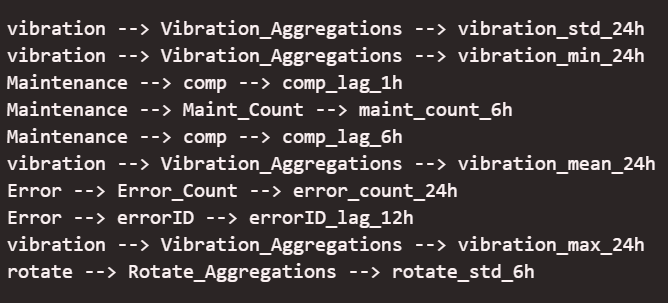

<br>

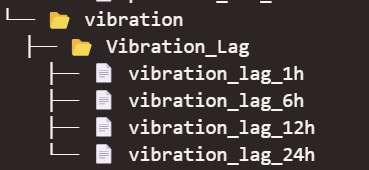


<br> <br> <br>

<hr style="height:10px; background-color:white; border:none;" />

# Why Counterfactual

#### Counterfactual analysis offers much more than just identifying important features (as SHAP does).



### 1. **Causal Insight**
Counterfactuals help you understand **how changing specific features would alter the model’s prediction**. This gives you a sense of “what if” scenarios and causal relationships, not just correlations.

### 2. **Actionable Recommendations**
They can suggest **minimal changes** needed to achieve a desired outcome (e.g., what needs to change for a machine to avoid failure).

### 3. **Model Robustness & Sensitivity**
By generating many counterfactuals, you can see **how stable or sensitive** the model’s predictions are to changes in input features.

### 4. **Fairness & Bias Detection**
Counterfactuals can reveal if certain groups or features unfairly influence predictions, helping to detect and mitigate bias.

### 5. **Transparency for End Users**
They provide **human-understandable explanations**: “If X had been higher, the prediction would have changed,” which is easier to interpret than feature importance scores.

### 6. **Scenario Planning**
Counterfactuals allow you to **simulate alternative scenarios** and assess the impact of interventions or policy changes.

---

**In summary:**  
Counterfactuals go beyond feature importance by showing how and why predictions change, supporting causal reasoning, actionable insights, robustness checks, fairness analysis, and scenario exploration.

<br> <br> <br>

---

### 1. **consistent_nodes**
- **What it is:**  
  A dictionary of features whose values remained (almost) unchanged across all counterfactual runs.
- **What you learn:**  
  These features are *robust*—perturbing other features does not affect them, and they do not need to change to alter the model’s prediction.  
  **Interpretation:** They are “stable” or “fixed” in the local causal structure for this instance.

---

### 2. **all_counterfactuals**
- **What it is:**  
  A DataFrame where each row is a counterfactual sample (i.e., a perturbed version of the original input).
- **What you learn:**  
  - You can see the range and distribution of feature values across all counterfactuals.
  - By comparing these rows, you can identify which features are most frequently or most strongly perturbed to achieve a prediction change.
  - You can also analyze which combinations of feature changes are most effective.

---

### 3. **logs**
- **What it is:**  
  A list of dictionaries, one per run, each containing:
  - The specific feature changes (old value, new value, perturbation) for that run.
  - The resulting model prediction.
- **What you learn:**  
  - **Feature-level impact:** See exactly how much each feature was changed in each run.
  - **Prediction sensitivity:** Track how the model’s output changes in response to different perturbations.
  - **Pathways to outcome:** Identify which feature changes (or combinations) are most likely to flip the prediction.

---

## **How to use these together**

- **Find stable vs. sensitive features:**  
  `consistent_nodes` tells you which features are stable; features not in this dict are more sensitive or variable.
- **Understand counterfactual diversity:**  
  `all_counterfactuals` shows the diversity of possible “worlds” (feature combinations) that could lead to different predictions.
- **Trace cause and effect:**  
  `logs` lets you trace, for each run, exactly what was changed and what the outcome was—helping you build a causal narrative.
- **Summarize model behavior:**  
  By aggregating over `logs`, you can see which features, when perturbed, most often lead to a change in prediction (and how large those changes need to be).

---

**In summary:**  
By examining `consistent_nodes`, `all_counterfactuals`, and `logs`, you can distinguish stable from sensitive features, see the range of plausible counterfactuals, and directly connect feature changes to prediction changes—providing deep, actionable, and causal insight into your model’s behavior.

<br> <br> <br> <br>

<hr style="height:10px; background-color:white; border:none;" />


# How the target variable is created 

The code creates a new `target` column in a sorted DataFrame (`df_sorted`) by analyzing future values of a specified column (`target_col`) over a given `prediction_horizon`. Here's a step-by-step breakdown:

### 1. **Rolling Window Calculation**  
```python
.rolling(window=prediction_horizon, min_periods=1).max()
```
- **Purpose**: Computes the **maximum value** within a sliding window of size `prediction_horizon` (e.g., 24 hours).  
- `min_periods=1`: Ensures a result is generated even if the window has fewer than `prediction_horizon` values (uses available data).  
- **Output**: For each row, this returns the max value of `target_col` over the **previous `prediction_horizon` rows** (including the current row).  

---

### 2. **Future Alignment**  
```python
.shift(-prediction_horizon)
```
- **Purpose**: Shifts the results **forward** by `prediction_horizon` positions.  
- **Why?**: Aligns the computed max value (from Step 1) with the **starting point** of the window it represents.  
  - Example: If `prediction_horizon=3`, the max value for rows `(t, t+1, t+2)` is assigned to row `t` (not `t+2`).  

---

### 3. **Handle Missing Values**  
```python
.fillna(0)
```
- Replaces `NaN` values (resulting from the forward shift where future data is unavailable) with `0`.  

---

### Key Outcome:  
The `target` column indicates:  
> **"The maximum value of `target_col` observed over the next `prediction_horizon` rows."**  

### Example Walkthrough:  
Assume `target_col` is `failure_flag` (binary: `1` = failure, `0` = no failure) and `prediction_horizon=3`:  

| Time | `failure_flag` | Step 1: Rolling Max (Past 3) | Step 2: Shift(-3) → `target` |
|------|----------------|-------------------------------|------------------------------|
| t0   | 0              | max(0) = **0**               | → Assigned to **t0**         |
| t1   | 0              | max(0,0) = **0**             | → Assigned to **t1**         |
| t2   | 1              | max(0,0,1) = **1**           | → Assigned to **t2**         |
| t3   | 0              | max(0,1,0) = **1**           | → Assigned to **t3**         |
| t4   | 0              | max(1,0,0) = **1**           | → `NaN` (filled with 0)      |
| t5   | 0              | max(0,0) = **0**             | → `NaN` (filled with 0)      |

- **Interpretation**:  
  - At `t0`, `target=0` → No failure in the next 3 steps.  
  - At `t1`, `target=0` → No failure in the next 3 steps.  
  - At `t2`, `target=1` → **Failure occurs in the next 3 steps** (at `t2` itself).  
  - At `t3`, `target=1` → **Failure occurs in the next 3 steps** (at `t2`).  

---

### Use Cases:  
- **Failure Prediction**: Flag if a failure (`1`) occurs within `prediction_horizon` steps.  
- **Peak Detection**: Identify if a value exceeds a threshold in the near future.  

### Note:  
- The DataFrame **must be sorted chronologically** (e.g., by timestamp) for accurate future alignment.  
- `min_periods=1` ensures no data loss at the beginning of the series.  
- Rows at the end of the DataFrame (with insufficient future data) default to `0`.

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />


## Check the way "Target" feature is desinged



```python

df_sorted['target'] = df_sorted["failure"].rolling(window=24, min_periods=1).max().shift(-24).fillna(0)

# Check the failure and target variables 24 hours before a failure occures
df_machine_original = pd.read_csv(f"../../data/azure_pm/machines/machine_{machine_number}.csv")
df_machine = pd.read_csv(f"../../data/azure_pm/lag_features/machine_{machine_number}_lag_features.csv")

display(df_machine_original.iloc[3223-24:3224][["datetime", "failure"]])
display(df_machine.iloc[3223-24:3224][["datetime","failure", "target"]])
```

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />

<br> <br> <br> <br> 


<hr style="height:10px; background-color:white; border:none;" />